In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [52]:
df=pd.read_csv("D:\Downloads\Project\Merge Dataset.csv")

In [53]:
df

,City,Hotel Name,Location,Distance,Rating,Review,No. of Reviews,Price
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ahmedabad,Taj Skyline,"Thaltej, Ahmedabad",10.3 km from centre,8.5,Very good,1045.0,8600.0
2,Ahmedabad,Four Points by Sheraton Ahmedabad,"Ellis Bridge, Ahmedabad",1.2 km from centre,8.2,Very good,615.0,7000.0
3,Ahmedabad,Artilla Inn,"Ellis Bridge, Ahmedabad (Ashram Road)",0.8 km from centre,8.1,Very good,811.0,4687.0
4,Ahmedabad,Le Meridien Ahmedabad,"SG Highway, Ahmedabad (SG Highway)",6.9 km from centre,7.8,Good,303.0,9000.0
...,...,...,...,...,...,...,...,...
1194,Pune,Teesta Suites,Pune,22.2 km from centre,9.2,Superb,19.0,2679.0
1195,Pune,Rutugandh Heritage,"Deccan, Pune",1.4 km from centre,6.1,Moderate,25.0,2100.0
1196,Pune,Hotel Royal Inn,Pune,10.1 km from centre,1.9,Moderate,8.0,899.0
1197,Pune,Treebo The Tree,"Pimpri, Pune (Hinjawadi)",19.7 km from centre,7.2,Good,34.0,2071.0


In [54]:
df.dtypes

City               object
Hotel Name         object
Location           object
Distance           object
Rating            float64
Review             object
No. of Reviews    float64
Price              object
dtype: object

In [55]:
df['Price'] = (
    df['Price']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
)

df['Price'] = pd.to_numeric(df['Price'], errors='coerce')


In [56]:
import matplotlib.pyplot as plt

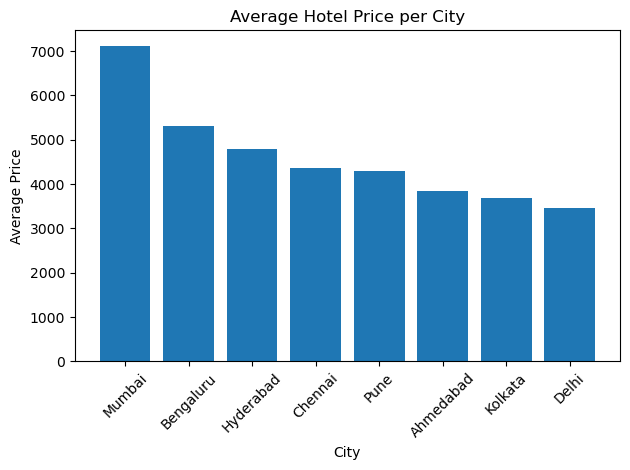

In [57]:
avg_price_city = df.groupby('City')['Price'].mean().sort_values(ascending=False)

plt.figure()
plt.bar(avg_price_city.index, avg_price_city.values)
plt.title("Average Hotel Price per City")
plt.xlabel("City")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

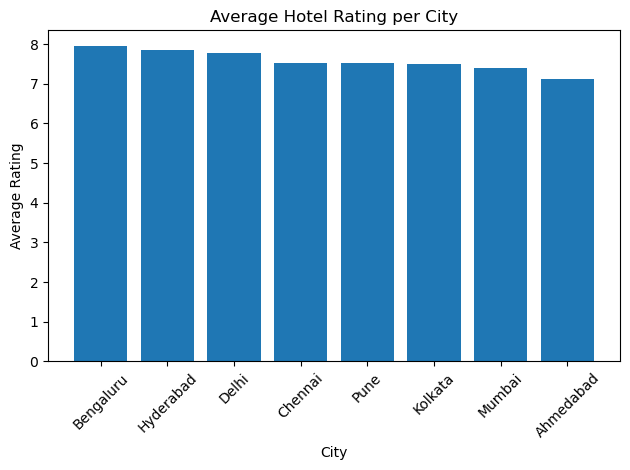

In [58]:
avg_rating_city = df.groupby('City')['Rating'].mean().sort_values(ascending=False)

plt.figure()
plt.bar(avg_rating_city.index, avg_rating_city.values)
plt.title("Average Hotel Rating per City")
plt.xlabel("City")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


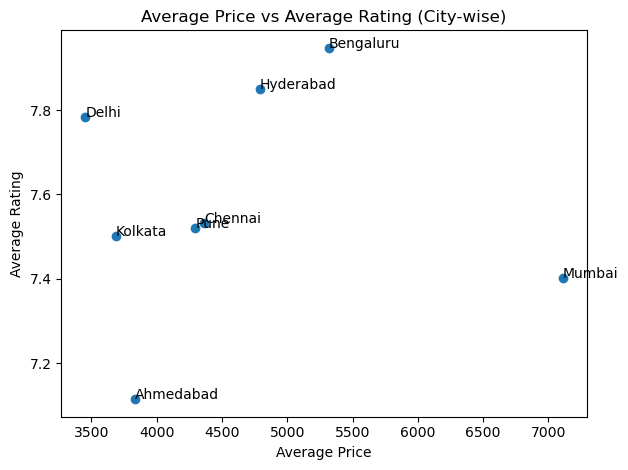

In [59]:
city_summary = df.groupby('City').agg({
    'Price': 'mean',
    'Rating': 'mean'
})

plt.figure()
plt.scatter(city_summary['Price'], city_summary['Rating'])

for city in city_summary.index:
    plt.text(city_summary.loc[city, 'Price'],
             city_summary.loc[city, 'Rating'],
             city)

plt.title("Average Price vs Average Rating (City-wise)")
plt.xlabel("Average Price")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.show()


In [61]:
import numpy as np
import matplotlib.pyplot as plt

# Create bins: 0–1000, 1000–2000, etc.
bins = np.arange(0, df['No. of Reviews'].max() + 1000, 1000)

df['Review_Bin'] = pd.cut(df['No. of Reviews'], bins=bins)


In [63]:
avg_rating_by_bin = (
    df.groupby('Review_Bin', observed=True)['Rating']
      .mean()
)

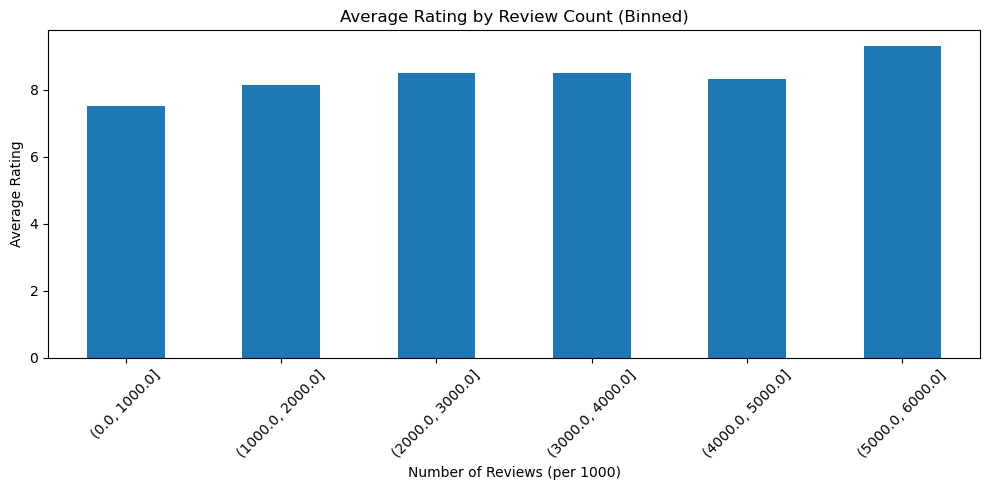

In [64]:
plt.figure(figsize=(10, 5))
avg_rating_by_bin.plot(kind='bar')

plt.title('Average Rating by Review Count (Binned)')
plt.xlabel('Number of Reviews (per 1000)')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()